In [7]:
import sys
import os
import ctypes


# Get the absolute path of the utils directory
utils_path = os.path.abspath("lib")
sys.path.append(utils_path)
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import qiskit.qpy as qpy
import pickle
import json
import matplotlib.patches as mpatches
from numba import njit
from numba.typed import List
from plotting import *
from readings import *
from tile_process import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
current_path = os.getcwd()
print("Current Path:", current_path)

Current Path: c:\Users\24835\Desktop\homework\uiuc\Covey\chem\H-chain\src


Missing module: mrh.exploratory.unitary_cc.uccsd_sym1, substituting with DummyMRH
[[2.007689989458828e-07, 0], [2.0076899894403988e-07, 1], [4.1911782145529535e-05, 2], [4.191178214552532e-05, 3], [-3.06404947523203e-05, 4], [-3.064049475232025e-05, 5], [2.748706645913103e-06, 6], [2.748706645913175e-06, 7], [1.0277114938956903e-07, 8], [1.0277114938964437e-07, 9], [1.9945701541732275e-05, 10], [1.994570154173223e-05, 11], [-3.9407204663140276e-07, 12], [-3.940720466293908e-07, 13], [8.849297499047938e-07, 14], [8.849297499079873e-07, 15], [-1.334438177673678e-06, 16], [-1.3344381776747219e-06, 17], [-3.2662473898548083e-07, 18], [-3.2662473898534626e-07, 19], [7.090247557489839e-06, 20], [7.090247557488946e-06, 21], [-8.262055951600106e-07, 22], [-8.262055951628805e-07, 23], [1.1904265616651142e-07, 24], [1.1904265616645895e-07, 25], [1.073148034433129e-05, 26], [1.0731480344330197e-05, 27], [-2.350398550067536e-08, 28], [-2.350398550022994e-08, 29], [7.4152361969007714e-06, 30], [7.4

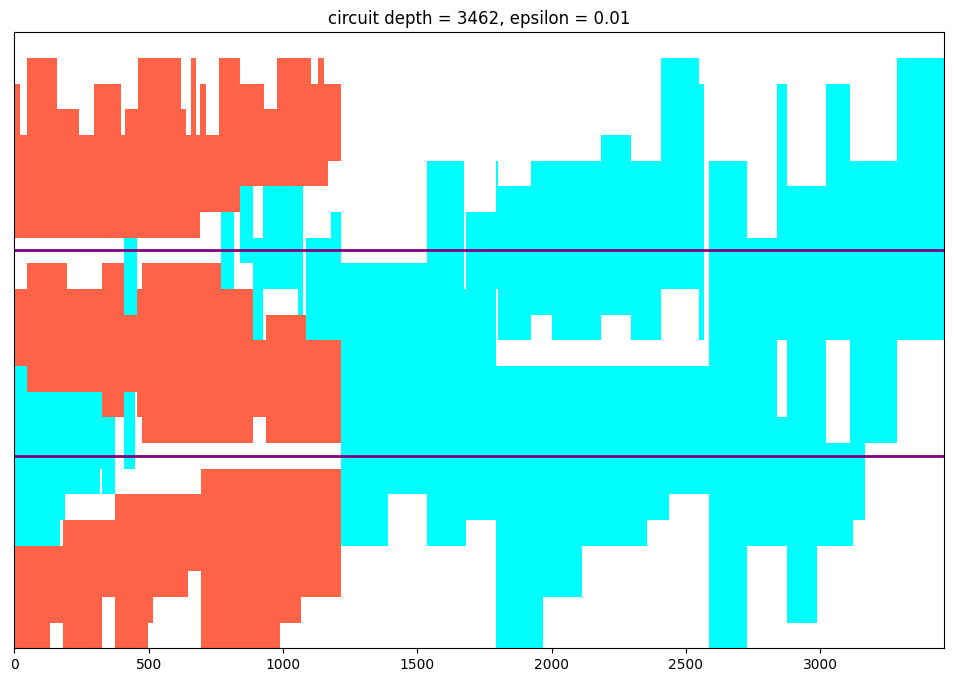

In [13]:
prehead = "../H_12_cluster/"
c_directory = "../src/lib/tile_packing.exe"

distance = 0.0
distance = float(distance)
read_epsilon = 1.0
# epsilon = 0.0093260334688322
epsilon = 0.01
seam_lst = [8,16]
f_orbs = (2,2,2,2,2,2)
N = 24
ratio = 1
uop, all_g = read_uop(distance, read_epsilon, prehead)
epsilon_lst = np.linspace(0.1,3,100)
epsilon_lst = 10**-(epsilon_lst)
print(all_g)


excitations = create_excitation(uop, all_g, epsilon)
print(len(excitations))
excitations = orbital_reordering(excitations, f_orbs)
tiles = create_circuit_tile(excitations)
tiles = process_tiles(tiles, ratio, seam_lst)
bounding_width, placed_tiles = packing_with_c(tiles, c_directory)
placed_tiles = TilePacker(placed_tiles, bounding_width, N)
placed_tiles.draw_packing([],seam_lst,epsilon)


In [10]:
prehead = "../H_12_cluster/"
distance = 1.0
distance = float(distance)
read_epsilon = 1.0
epsilon = 0.007778737048694311
seam_lst = [8,16]
f_orbs = (2,2,2,2,2,2)
N = 24
ratio = 4
uop, all_g = read_uop(distance, read_epsilon, prehead)
epsilon_lst = np.linspace(0.1,3,100)
epsilon_lst = 10**-(epsilon_lst)
print(all_g)


excitations = create_excitation(uop, all_g, epsilon)
print(len(excitations))
excitations = orbital_reordering(excitations, f_orbs)
tiles = create_circuit_tile(excitations)
tiles = process_tiles(tiles, ratio, seam_lst)
bounding_width, placed_tiles = packing_with_c(tiles)
placed_tiles = TilePacker(placed_tiles, bounding_width, N)
placed_tiles.draw_packing([],seam_lst,epsilon)


Missing module: mrh.exploratory.unitary_cc.uccsd_sym1, substituting with DummyMRH
[[-5.691350756235726e-07, 0], [-5.691350756237369e-07, 1], [3.60138657072578e-05, 2], [3.601386570725641e-05, 3], [-3.584429337516161e-05, 4], [-3.584429337516042e-05, 5], [5.972922845095476e-07, 6], [5.97292284506727e-07, 7], [8.69314382623625e-09, 8], [8.693143826182093e-09, 9], [2.112584276844532e-06, 10], [2.112584276844315e-06, 11], [3.2585053827599064e-08, 12], [3.2585053827836246e-08, 13], [8.879768183891057e-07, 14], [8.879768183891635e-07, 15], [-9.306800789927478e-07, 16], [-9.306800789929265e-07, 17], [-3.950539938270618e-08, 18], [-3.95053993826922e-08, 19], [-8.781884552139584e-07, 20], [-8.781884552150982e-07, 21], [-3.406178944825479e-08, 22], [-3.406178944824792e-08, 23], [-5.748719221074587e-09, 24], [-5.748719221061035e-09, 25], [1.2122335248492198e-06, 26], [1.2122335248492971e-06, 27], [-3.62455436271173e-09, 28], [-3.624554362655771e-09, 29], [9.570991987637846e-07, 30], [9.5709919876

TypeError: packing_with_c() missing 1 required positional argument: 'c_directory'